# 2st Notebook: Sample classification with a DNN


## 1. Reading the datasets

<p> First, we read the NumPy arrays that were generated with the previous Notebook. We count with a pickle file that contains: </p>
<ul>
    <li> <strong> x_train: </strong> A NumPy array with the samples that are going to train the DNN. </li>
    <li> <strong> y_train: </strong> A NumPy array with the labels (0's o 1's) that indicate the class ('signal' or 'background') of the samples contained in <strong>x_train</strong>. </li>
    <li> <strong> x_test: </strong> A NumPy array with the samples that are going to evaluate the DNN performance. </li>
    <li> <strong> y_test: </strong>  A NumPy array with the labels (0's o 1's) that indicate the class ('signal' or 'background') of the samples contained in <strong>x_test</strong>. This labels will allow to compute the success rate of the DNN.</li>
</ul>

The NumPy arrays are extracted from the pickle file with the command ```load()```. An example of storing/loading python variables in pickle format is available [here](https://wiki.python.org/moin/UsingPickle).

In [1]:
%reset -f
import pickle
import numpy as np

#filename = '/home/jovyan/share/Training/DNNtraining_variables.p'
filename = 'DNNtraining_variables.p'

with open(filename, 'rb') as file_:
    x_train, y_train, x_test, y_test = pickle.load(file_)
    
print(len(x_train))

318666


## 2. Keras environment setup

To classify the samples with the DNN it is necessary to build the model, then compile it and finally train it. In this practical exercise we work with [keras](https://keras.io/), a module that allows to build the DNN by adding layers and setting activation functions in an easy and handy way.

First, we need to import the Keras packages that are necessary for the training, that include, among other things:
- ```callbacks``` to access the training process information e.g. loss and accuracy values after each epoch.
- Modules to include the DNN layers, activation functions or different implementations to reduce overfitting such as *dropout* or *regularizers*.
- Optimizers to define the gradient descent algorithm e.g. ```RMSprop```
- The Keras backend over which the DNN is build. In this case we will work with **Tensorflow** (although other options, such as **Theano** are possible).

In addition, we also import a module called ```history_tools.py``` which is available in this same repository. It will provide everything necessary to process the callback information when the DNN is training. On one hand, it defines a class ```LossHistory``` that serves to build an instance as the DNN training process evolves. On the other hand, it also imports a function ```plot_history()``` that will receive this instance and plot the information.

In [2]:
import keras
import keras.callbacks as cb
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Input
from keras import regularizers
from keras import backend as K
from keras import optimizers
from keras.optimizers import RMSprop, Adam, SGD
from keras import callbacks
import keras.backend as K
import time
import os 


import numpy as np

2026-03-31 13:56:11.816143: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 3. DNN creation

Before starting the training process, we need to design the architecture of the DNN and then build it. Esentially, we have to decide:
- The number of layers of the DNN.
- The number of neurons of each layer.
- The activation functions of each layer, specially the last one.
- The optimizer.
- Other functions that could be implemented layer by layer to reduce overfitting e.g. dropout or regularizers.

Keras offers two different configurations to build neural networks architectures: The [sequential mode](https://keras.io/getting-started/sequential-model-guide/) and the [functional-api](https://keras.io/getting-started/functional-api-guide/). The later is normally used in problems way more complex that the one treated in this exercise. The DNN that we want to create can be easily build with sequential models, adding layers in a linear way (we encourage you to use this mode).

---

**TO DO: Define a sequential model and call it ```model```. Then, generate a fully connected network with the following neuron distribution in each one of the hidden layers: ```(30, 20, 20, 10, 10, 10, 5)```. Remember that we are dealing with a binary classification problem: how many neurons must contain the last layer? Remember to include the activation functions recommended in class for each layer.**

In [3]:
# number of features:
n_features = x_train.shape[1]
print(f"There are {n_features} features in the training data.")
# number of instances:
n_instances = x_train.shape[0]
print(f"There are {n_instances} training instances in the training data.")

There are 30 features in the training data.
There are 318666 training instances in the training data.


In [4]:
K.clear_session() # always clean up the memory before trying a new training 

### my code starts here
# we will use Sequential API
model_0 = Sequential()
model_0.add(Input(shape=(n_features,)))
model_0.add(Dense(30, activation='relu'))
model_0.add(Dense(20, activation='relu'))
model_0.add(Dense(20, activation='relu'))
model_0.add(Dense(10, activation='relu'))
model_0.add(Dense(10, activation='relu'))
model_0.add(Dense(10, activation='relu'))
model_0.add(Dense(5, activation='relu'))
# Final layer:
model_0.add(Dense(1, activation='sigmoid'))

In [5]:
# I like to use model.summary() to check the model architecture, and the number of trainable parameters
model_0.summary()  

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 30)                930       
                                                                 
 dense_1 (Dense)             (None, 20)                620       
                                                                 
 dense_2 (Dense)             (None, 20)                420       
                                                                 
 dense_3 (Dense)             (None, 10)                210       
                                                                 
 dense_4 (Dense)             (None, 10)                110       
                                                                 
 dense_5 (Dense)             (None, 10)                110       
                                                                 
 dense_6 (Dense)             (None, 5)                 5

## 4. Compilation

When the DNN model ```model``` is already built i.e having the layer architecture, activation functions... etc correctly defined, the model has to be compiled.

In the compilation step we need to decide the **loss function**, **the optimizer**, and also the **metrics** that will be used to monitorize the training process:

---
> The **loss function** $L(\hat{y}, y)$ is a value that quantifies the discrepancy between the network predictions and the ground truth i.e. it is a definition of the error in the classification. Each time that the network ends to read a batch of samples and predicts the labels, it computes the loss value and tries to minimize it. The results of the training process depends on how this error value is defined. 
>
> You can find [here](https://keras.io/losses/) some of the functions already defined in Keras. Normally, ```categorical_crossentropy``` is used in multiclass classification problems, while ```binary_crossentropy``` is used in binary ones.
---
> The **optimizer** is an optimization algorithm that is used to minimize the loss and adjust the weights of the network gradually. Optimizers already defined in Keras can be found [here](https://keras.io/optimizers/). Some examples of them are ```SGD```, ```RMSprop``` or ```Adam```.
---
> The **metrics** is an auxiliar function that is used to define a value to evaluate the network performance while it is training. The recomended metrics for this problem is the ```accuracy``` value provided by Keras.
---
---

**TO DO: In this part of the Notebook you have to compile your neuronal network. For the first trial use ```binary_crossentropy``` as the loss function and try to minimize it using the ```SGD``` optimizer. Include in your ```metrics``` the accuracy.**

In [6]:
# resources: https://www.tutorialspoint.com/keras/keras_model_compilation.htm
model_0.compile(
loss = 'binary_crossentropy',
optimizer = 'SGD',
metrics = ['accuracy']
)
print('Model compiled')

Model compiled


## 5. Last considerations before training: Sample format

At this point the architecture of the network is already defined and compiled. It is now when we have to check the consistency between the format of the inputs and the network we are about to train.

Firstly, we have to check that the samples can be read by the DNN. We have to make sure that the network is expecting vectors of a dimension that matches the one of the input i.e. if the samples are 30-dimensional vectors, the DNN should be built to read exactly that.

Secondly, we have to keep in mind that the network is going to compare its predictions and the input label vectors (y_train and y_test). So they are expected to have the same format:

> If the DNN is a binary network the label need to be given in nEvents x 1 ```numpy.array``` with an unique element per sample that indicates the class:
>
>```
y = numpy.array([[1],
                 [0],
                 [1],
                 [1],
                 ...,
                 [0]])
>```

> If, on the contrary, we are dealing with $N$ classes ($N > 2$) the label vector needs a higher dimensional nEvents x $N$ ```numpy.array``` (one element per class). All the entries of each row (row = Event) will be 0 excluding the one that corresponds to the correct class. For example, the last vector ($N = 2$) will be writen as:
>```
>y = numpy.array([[0, 1],
                 [1, 0],
                 [0, 1],
                 [0, 1],
                 ...,
                 [1, 0]])
>```



In [7]:
print("y_train:")
print(y_train)
print("-----")
print("y_test:")
print(y_test)
print("-----")

y_train:
[[1.]
 [1.]
 [1.]
 ...
 [1.]
 [0.]
 [1.]]
-----
y_test:
[[0]
 [0]
 [1]
 ...
 [0]
 [1]
 [0]]
-----


In [8]:
# good to have checked, we should convert the y_train vector to integer format
y_train = y_train.astype(int) 
print(y_train)
print("now we are ready to go :)")

[[1]
 [1]
 [1]
 ...
 [1]
 [0]
 [1]]
now we are ready to go :)


## 6. Neural network training 

Now we need to define the characteristics of the training process i.e. which samples will the DNN use, how many times it will read them, in how many steps, the callbacks... etc.

In first place it is recomended to create an instance of the class ```LossHistory```, imported in previous steps. This object is basically a container of **information about the training process**. It stores the accuracy and loss values at the end of every epoch. In order to be updated in this way, it is given as a ```callbacks``` parameter to the DNN.

The **number of epochs** also needs to be defined, that is, the number of times that the DNN reads the entire train dataset ```x_train```. It is important to keep in mind that we must reach a compromise between two opposite effects:
- If the number of epochs is very small, it is possible that the network does not have enough time to extract the information and learn how to classify the samples properly. In this happens, events would be classified randomly.
- If the number of epochs is too big, **overfitting** may happen. Overfitting is the challenge of machine learning and it basically means that *the network has learnt too much*, even the tiny details in which we do not want to base our classification criteria. The DNN could be able to learn systematic effects, fluctuations... that may prevent itself to generalize the model to the test dataset.

We also have to define the **batch size** i.e. the number of samples read in each iteration inside an epoch. The network reads the set of samples in the batch, computes the loss, optimizes the weights and reads the next batch until the epoch ends. And it starts again.

---

The DNN model, defined in the python variable ```model``` is trained by means of the function ```fit``` that takes as main parameters:

1. The dataset ```x_train``` and its labels ```y_train``` of the events used to train the network.
2. The number of epochs ```epochs```.
3. The batch size ```batch_size```.
4. The ```verbose``` level that sets how much infomation about the training do we want to print.
6. A boolean value ```shuffle``` that alters the original order of the datasets given as the input. We already shuffled the samples in the previous notebook, but it is advisable to turn this parameter ```True``` anyway. 
7. The history of the training is stored in the ```training``` variable

---

**TO DO: For now, train the DNN during 20 epochs fixing a ```batch_size``` of 512. Use as validation set a 10% portion of the training dataset and make sure that you are shuffling your samples.**

In [9]:
import time
import numpy as np

print('Training model...')

n_epochs = 20
n_batch = 512
val_size = 0.1 # size of the validation dataset (in percentage of the train dataset)

from sklearn.model_selection import train_test_split as tts

x_train, x_val, y_train, y_val = tts(
    x_train, y_train, 
    test_size=val_size,
    shuffle = True,
    random_state=42,
    stratify = y_train
)


start_time = time.time()

training = model_0.fit(x_train, y_train, 
                       batch_size=n_batch,
                       epochs=n_epochs,
                       validation_data=(x_val, y_val), #
                       verbose=0)
# all the training process will be stored in the object "training", which is intended to be accessed after training

end_time = time.time()
print("Training duration : {0}".format(end_time - start_time) + " secs")


Training model...
Training duration : 72.09409642219543 secs


## 7. Save the training information

Once trained, the network weights are fixed and the network can be used to classify other samples that have not been used to train it. Saving the trained model implies saving the architecture (layer number, neurons, dropout... etc) but also **saving the network weights**. In this way, it is possible to use this trained DNN to classify whatever we want without training it again and again.

---

**TO DO: Save your model in ```.h5``` format in the ```Models/``` folder. Check first if this directory exists and if it does not, create it.**

In [10]:
!ls

DNNTraining.ipynb	 Keras_QuickGuide.html	Registry.ipynb
DNNtraining_variables.p  Models			training.csv
Histograms		 PrepareSamples.ipynb
History			 README.txt


In [11]:
!mkdir ./Models
!ls

mkdir: cannot create directory ‘./Models’: File exists
DNNTraining.ipynb	 Keras_QuickGuide.html	Registry.ipynb
DNNtraining_variables.p  Models			training.csv
Histograms		 PrepareSamples.ipynb
History			 README.txt


In [12]:
model_0.save("./Models/my_first_model.h5")
model_0.save("./Models/my_first_model_KerasFormat.keras") # Keras starts complaining for h5 format
!ls ./Models

/opt/conda/lib/python3.11/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


my_first_model.h5  my_first_model_KerasFormat.keras


## 8. Loss and accuracy study

To check if the training process succeded we have to study the evolution of loss and accuracy. We expect a decrease in the loss value, pointing out that the error in the classification is decreasing as well. On the other hand, we expect an increase in the accurary that would imply that the DNN is becoming more capable of classifying the samples in their correct class.

Both values, loss and accuracy, are plotted vs the number of epochs to see the evolution. In most cases we will observe the decrease in the loss and increase in accuracy for the **training set**.

However, the behavior of the **validation set** is more complex and will give an idea of how to opmitize the learning process. As the samples of this dataset are different from the ones used to train the network, the performance would be slightly worse.

Overfitting manifests itself in the loss and accuracy evolution. When the network starts to learn undesired patterns from the training set that can not be extrapolated to the validation set, the loss stops its decrease and starts to grow up. Consequently, accuracy gets reduced at this point.

Both the accuracy and loss are stored in training.history['acc'] and training.history['loss'] respectively. You can find the loss of the validation set in training.history['val_loss']

---

**TO DO: Check if folder ```History/``` exists and if not, create it. Then plot the loss and accuracy versus the epoch number. Plots will be automatically saved in this folder.**



In [13]:
!ls

DNNTraining.ipynb	 Keras_QuickGuide.html	Registry.ipynb
DNNtraining_variables.p  Models			training.csv
Histograms		 PrepareSamples.ipynb
History			 README.txt


In [14]:
!mkdir ./History

mkdir: cannot create directory ‘./History’: File exists


In [15]:
keys = training.history.keys() # to access all the information avaliable
print(keys)

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


In [16]:
# all the information is stored in the object "training", as we stated before
import os
path = "/home/jovyan/Higgs-ML-Challenge"
os.chdir(path)

import matplotlib.pyplot as plt

epochs = training.epoch
val_loss = training.history['val_loss']
val_acc = training.history['val_accuracy']
tr_loss = training.history['loss']
tr_acc = training.history['accuracy']
show = False

plt.figure()
plt.plot(epochs,tr_loss, label='Train Loss')
plt.plot(epochs,val_loss, label='Validation Loss')
plt.title("Loss vs epochs")
plt.legend()
plt.xlabel("epochs")
plt.grid(True)
plt.savefig("History/Loss_evolution_model0.png")
if show:
    plt.show()
else:
    plt.close()
    
plt.figure()
plt.plot(epochs, tr_acc, label='Train accuracy')
plt.plot(epochs,val_acc, label='Validation accuracy')
plt.grid(True)
plt.legend()
plt.xlabel("epochs")
plt.title("Accuracy vs epochs")
plt.savefig("History/Accuracy_evolution_model0.png")
if show:
    plt.show()
else:
    plt.close()

print("Both figures saved correctly at ./History directory")

## APPROXIMATE RESULTS: 83% VAL ACCURACY, cannot confirm ovefitting for only 20 epochs
### Pending: add regularization and optimize hyperparameters

Both figures saved correctly at ./History directory


<strong>TO DO:

Now repeat the last steps with the following modifications:

- Use the RMSprop optimizer
- Use the Adam optimizer

What optimizer works better?

Using the one that have the best performance: Do you observe something weird in the plot by comparing the accuracy of the train and validation datasets?

- Try to decrease the learning rate value

What do you observe now?

</strong>



In [17]:
# for efficiency, we pipeline the whole process into a modular function

def define_mlp(optimizer, 
               LR:float,
               epochs:int = 40, 
               Patience_Early_Stopping:int = 5,
               batch_size:int = 512, 
               LR_Decrease:float = 0,
               dropout_rate:float = 0,
               save_plots:bool = False,
               show:bool = False,
               array_neurons_hidden:list = None):
    """
    Complete 'fully connected' Dense Neural Network (a.k.a. Multi-Layer Perceptron)
    Task: classify as signal(1) / background(0) the data from Higgs ML Challenge
    
    optimizer:str = SGD, RMSprop, Adam, ...
    LR:float = learning rate. Works if the optimizer is Adam, RMSprop, decreased Gradient Descent    
    epochs:int
    early_stopping:int = when to stop training if the model is not "learning propperly" anymore
    array_neurons:list = list with the neurons in each of the layers
    dropout_rate
    the training/val partition will be fixed with previous definition for legit comparisons between models
    """
    from tensorflow.keras import backend as K
    import gc
    

    
    K.clear_session()
    gc.collect()
    
    
    # Default architecture 
    if array_neurons_hidden is None:
         array_neurons_hidden = [30, 20, 20, 10, 10, 10, 5]
         structure:str = 'Default'
    else:
        structure:str = 'Modified'
        layers:int = len(array_neurons_hidden)
        neurons:int = int(np.sum(np.array(array_neurons_hidden)))
        
    # Definition of the architecture
    model = Sequential()
    model.add(Input(shape=(n_features,)))
    for i in array_neurons_hidden:
        model.add(Dense(i, activation='relu')) # as Niccolo taught us
        model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation="sigmoid"))
    print('Architecture defined successfully ----- [CORRECT]')
    
    # compilation --> optimizer selected by the user
    if optimizer == 'Adam':
        opt = Adam(learning_rate=LR)
    elif optimizer == 'RMSprop':
        opt = RMSprop(learning_rate=LR)
    elif optimizer == 'SGD': #stochastic gradient descent
        opt = SGD(learning_rate=LR)
    
    model.compile(
        loss='binary_crossentropy',
        optimizer=opt,
        metrics=['accuracy']
    )    
    print('Model compiled successfully ----- [CORRECT]')

    # CALLBACKS: EARLY-STOPPING
    from keras.callbacks import EarlyStopping
    early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=Patience_Early_Stopping,
    verbose=1,                                                # Prints a message when it stops
    restore_best_weights=True                                 # Keeps the best version of the model
    )    
    print('Callbacks defined ----- [CORRECT]')


    # TRAINING
    start_time = time.time()
    
    training = model.fit(x_train, y_train, 
                       batch_size=batch_size,
                       epochs=epochs,
                       validation_data=(x_val, y_val),
                       callbacks=[early_stop],
                       verbose=0)

    print('Model fully trained ----- [CORRECT]')
    end_time = time.time()
    print("Training duration : {0}".format(end_time - start_time) + " secs")


    # save the results of the training:
    # not really needed for now


    ### Visualization and saving
    import os
    path = "/home/jovyan/Higgs-ML-Challenge"
    os.chdir(path)
    
    import matplotlib.pyplot as plt
    
    epochs = training.epoch
    val_loss = training.history['val_loss']
    val_acc = training.history['val_accuracy']
    tr_loss = training.history['loss']
    tr_acc = training.history['accuracy']
    
    print(f"Best accuracy obtained (validation): {np.max(val_acc)}")

    
    if save_plots:
    
        plt.figure()
        plt.plot(epochs,tr_loss, label='Train Loss')
        plt.plot(epochs,val_loss, label='Validation Loss')
        plt.title(f"Loss vs epochs. {optimizer}, LR={LR}, structure {structure}")
        plt.legend()
        plt.xlabel("epochs")
        plt.grid(True)
        if structure == 'Default':
            plt.savefig(f"History/Loss_evolution_Optimizer{optimizer}_LR{LR}_Structure{structure}.png")
        else:
            plt.savefig(f"History/Loss_evolution_Optimizer{optimizer}_LR{LR}_Structure{structure}_Layers{layers}_Neurons{neurons}.png")

        if show:
            plt.show()
        else:
            plt.close()
            
        plt.figure()
        plt.plot(epochs, tr_acc, label='Train accuracy')
        plt.plot(epochs,val_acc, label='Validation accuracy')
        plt.grid(True)
        plt.legend()
        plt.xlabel("epochs")
        plt.title(f"Accuracy vs epochs. {optimizer}, LR={LR}, structure {structure}")
        if structure == 'Default':
            plt.savefig(f"History/Accuracy_evolution_Optimizer{optimizer}_LR{LR}_Structure{structure}.png")
        else:
            plt.savefig(f"History/Accuracy_evolution_Optimizer{optimizer}_LR{LR}_Structure{structure}_Layers{layers}_Neurons{neurons}.png")
        if show:
            plt.show()
        else:
            plt.close()
        
        print("Both figures saved correctly at ./History directory")

    
    return model, training

Architecture defined successfully ----- [CORRECT]
Model compiled successfully ----- [CORRECT]
Callbacks defined ----- [CORRECT]
Model fully trained ----- [CORRECT]
Training duration : 136.85678505897522 secs
Best accuracy obtained (validation): 0.8252424001693726


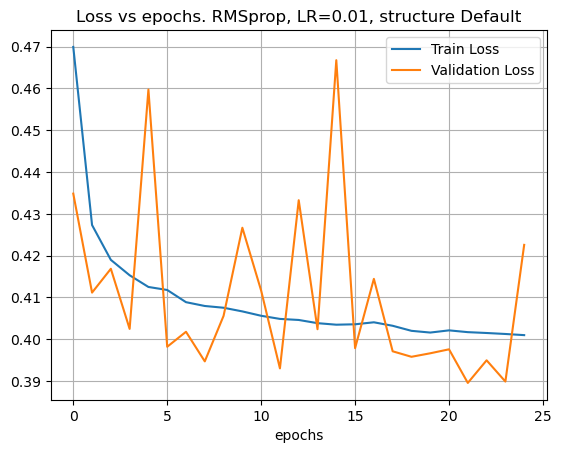

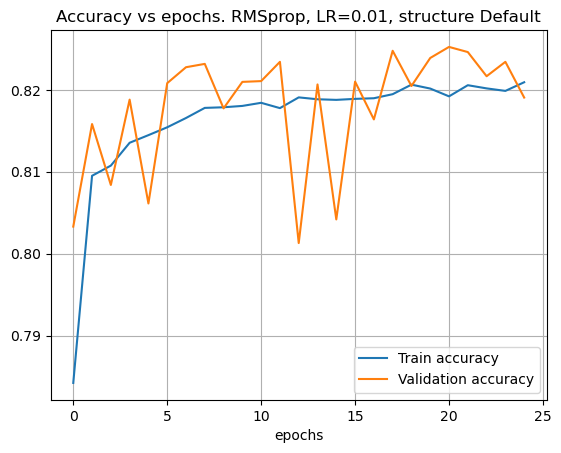

Both figures saved correctly at ./History directory


In [18]:
# ENTER YOUR CODE HERE (RMSprop + performance plots)

model_RMSprop, training_RMSprop = define_mlp(optimizer = 'RMSprop', 
LR = 0.01,
epochs = 25, 
Patience_Early_Stopping = 10,
batch_size = 512,
dropout_rate = 0.05,
LR_Decrease = 0,
save_plots = True,
show = True,
array_neurons_hidden = None) # None = default


Architecture defined successfully ----- [CORRECT]
Model compiled successfully ----- [CORRECT]
Callbacks defined ----- [CORRECT]
Restoring model weights from the end of the best epoch: 22.
Epoch 32: early stopping
Model fully trained ----- [CORRECT]
Training duration : 173.81322073936462 secs
Best accuracy obtained (validation): 0.8255248665809631


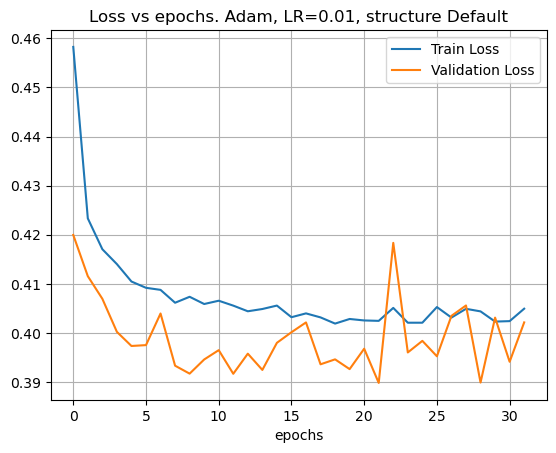

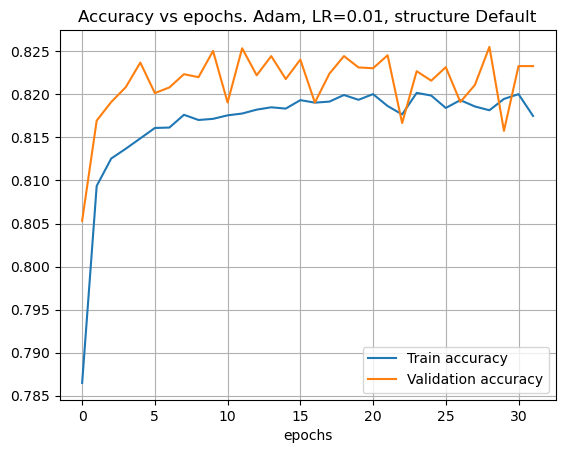

Both figures saved correctly at ./History directory


In [19]:
# ENTER YOUR CODE HERE (Adam + performance plots)
model_Adam, training_Adam = define_mlp(optimizer = 'Adam', 
LR = 0.01,
epochs = 50, 
Patience_Early_Stopping = 10,
batch_size = 512,
dropout_rate = 0.05,
LR_Decrease = 0,
save_plots = True,
show = True,
array_neurons_hidden = None) # None = default

# performance plots labeled and stored correctly at ./History


Architecture defined successfully ----- [CORRECT]
Model compiled successfully ----- [CORRECT]
Callbacks defined ----- [CORRECT]
Model fully trained ----- [CORRECT]
Training duration : 261.57566928863525 secs
Best accuracy obtained (validation): 0.8300750255584717


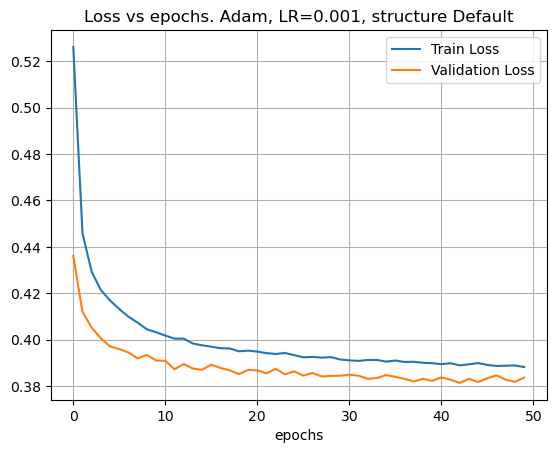

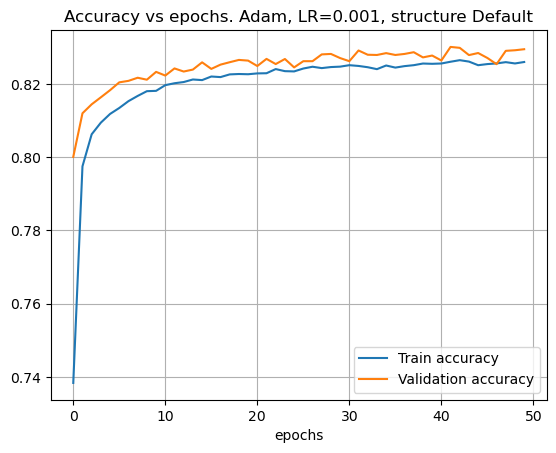

Both figures saved correctly at ./History directory


In [20]:
# ENTER YOUR CODE HERE (decreased learning rate + performance plots)
model_DLR, training_DLR = define_mlp(optimizer = 'Adam', 
LR = 0.001,
epochs = 50, 
Patience_Early_Stopping = 10,
batch_size = 512,
dropout_rate = 0.05,
LR_Decrease = 0.1,
save_plots = True,
show = True,
array_neurons_hidden = None)
# performance plots labeled and stored correctly at ./History


Architecture defined successfully ----- [CORRECT]
Model compiled successfully ----- [CORRECT]
Callbacks defined ----- [CORRECT]
Restoring model weights from the end of the best epoch: 40.
Epoch 50: early stopping
Model fully trained ----- [CORRECT]
Training duration : 266.4589719772339 secs
Best accuracy obtained (validation): 0.8286942839622498


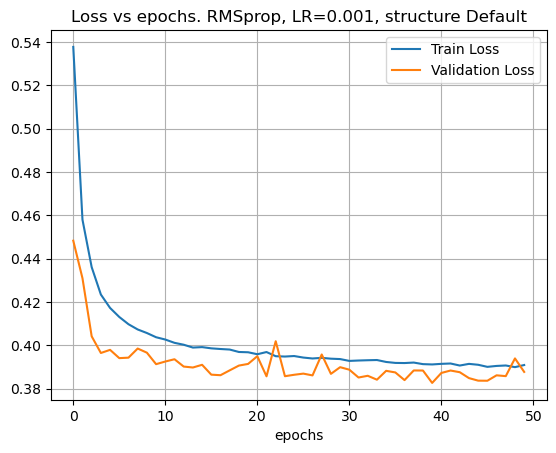

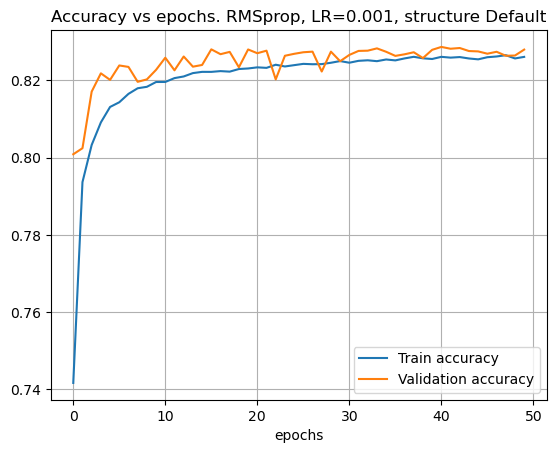

Both figures saved correctly at ./History directory


In [21]:
# ENTER YOUR CODE HERE (decreased learning rate + performance plots)
model_DLR, training_DLR = define_mlp(optimizer = 'RMSprop', 
LR = 0.001,
epochs = 50, 
Patience_Early_Stopping = 10,
batch_size = 512,
dropout_rate = 0.05,
LR_Decrease = 0,
save_plots = True,
show = True,
array_neurons_hidden = None)
# performance plots labeled and stored correctly at ./History


Architecture defined successfully ----- [CORRECT]
Model compiled successfully ----- [CORRECT]
Callbacks defined ----- [CORRECT]
Model fully trained ----- [CORRECT]
Training duration : 402.2554225921631 secs
Best accuracy obtained (validation): 0.8246461749076843


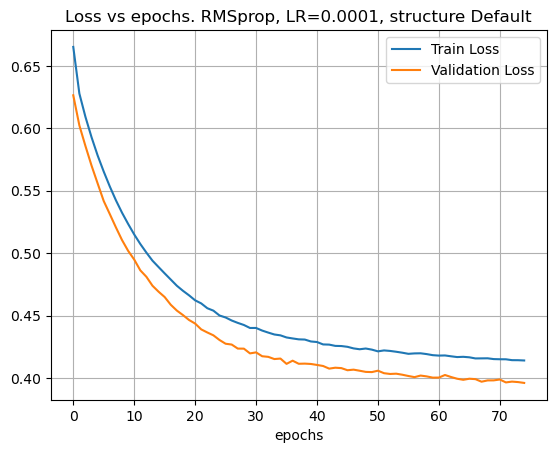

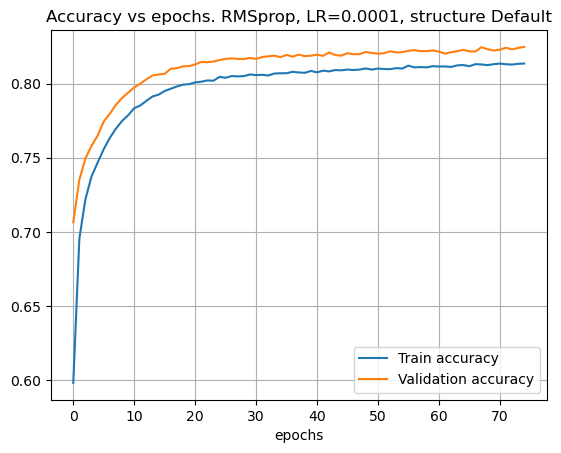

Both figures saved correctly at ./History directory


In [22]:
# if we squeeze even more, by decreasing the LR and increasing the number of epochs: 
model_DLR, training_DLR = define_mlp(optimizer = 'RMSprop', 
LR = 0.0001,
epochs = 75, 
Patience_Early_Stopping = 10,
batch_size = 512,
dropout_rate = 0.05,
LR_Decrease = 0,
save_plots = True,
show = True,
array_neurons_hidden = None)

### So what happens when LR is decreased?

With larger "steps", in each iteration the direction (in parameter space where the model moves through) is heavily updated. Changes are so big in the direction that the model can start an oscillating-like motion around the optimum parameter configuration. We can see this clearly in both: loss and accuracy measurements, for the higher LR (=0.05).

With smaller "steps", produced by a smaller LR, the model reaches the direction of the searched minimum in a slower but more stable way. Sometimes more epochs will be required with a small LR (which turns into more computation time), but we avoid the oscillations previously mentioned. 

Accuracy metric can be used as a proxy to find the best model. In the previous case, a ~3% difference in accuracy is reached just by decreasing the LR by 1 order of magnitud. 

Also, Adam seem to converge much better than RMSprop, which shows very large oscillations

Another comment on the last figure, val_accuracy can sometimes outperform train_accuracy. This is due mainly to Dropout, which deactivates some neurons during training, but they are activated during the validation calculations. Also, we have oversampled our training dataset by simple duplication of the events, which causes a potential data leakage between training and validation sets (this is why validation performance is just a proxy, we will take the test performance as the real sample of performance in new data for the model).

<strong> HINT: To avoid overfitting, it would probably be worth adding (with the best optimizer/learning rate choice you made) a ```callback``` with ```EarlyStopping``` (see documentation [here](https://keras.io/callbacks/)). In the ```EarlyStopping``` option, use ```val_loss``` value as reference and wait some epochs (10-20) before to stop the training. 

Fell free to change the parameters and to play with different architectures. Save in registry.ipynb a summary of the different configurations you tried, including the motivation of each architecture tested, and the improvements you got from each. </strong>

Architecture defined successfully ----- [CORRECT]
Model compiled successfully ----- [CORRECT]
Callbacks defined ----- [CORRECT]
Model fully trained ----- [CORRECT]
Training duration : 293.56000089645386 secs
Best accuracy obtained (validation): 0.8015502095222473


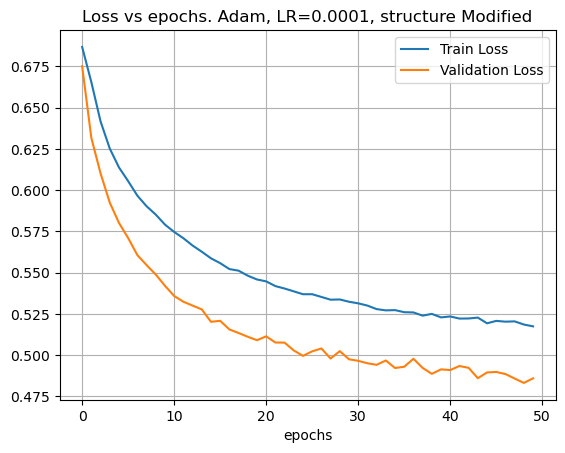

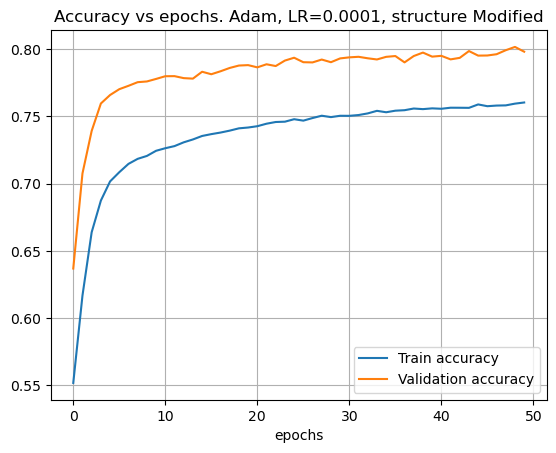

Both figures saved correctly at ./History directory
Architecture defined successfully ----- [CORRECT]
Model compiled successfully ----- [CORRECT]
Callbacks defined ----- [CORRECT]
Model fully trained ----- [CORRECT]
Training duration : 228.87193274497986 secs
Best accuracy obtained (validation): 0.8249285817146301


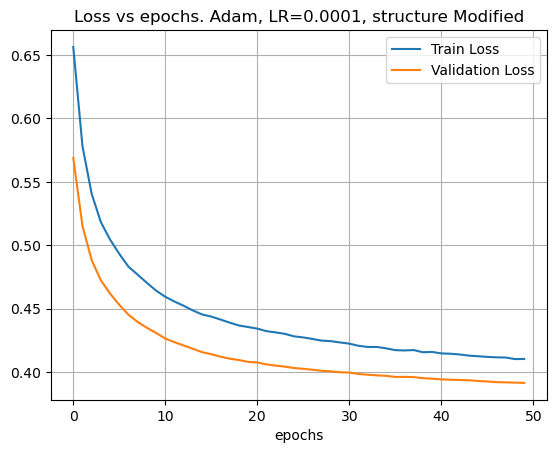

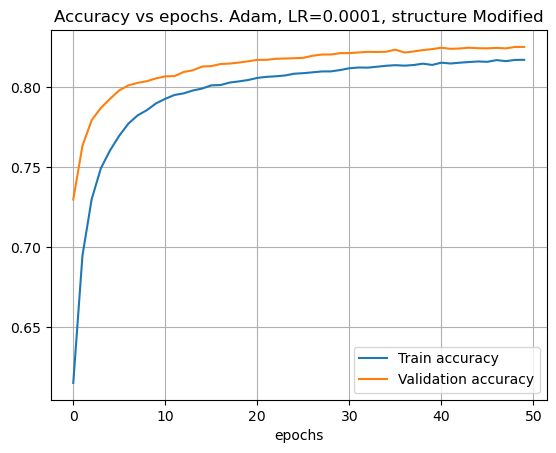

Both figures saved correctly at ./History directory


In [23]:
# TEST: more layers, less neurons, higher dropout than before, more epochs (not afraid of this, bc we have early stopping)
# will be using ADAM, which had shown better performance for our case

model_long, training_long = define_mlp(optimizer = 'Adam', 
LR = 0.0001,
epochs = 50, 
Patience_Early_Stopping = 10,
batch_size = 512,
dropout_rate = 0.1,
LR_Decrease = 0,
save_plots = True,
show = True,
array_neurons_hidden = [20, 15, 10, 10, 10, 5, 5, 5, 5, 3, 2]) # modified structure


# TEST: Less layers, more neurons

model_short, training_short = define_mlp(optimizer = 'Adam', 
LR = 0.0001,
epochs = 50, 
Patience_Early_Stopping = 5,
batch_size = 512,
dropout_rate = 0.1,
LR_Decrease = 0,
save_plots = True,
show = True,
array_neurons_hidden = [40, 30, 8])



Architecture defined successfully ----- [CORRECT]
Model compiled successfully ----- [CORRECT]
Callbacks defined ----- [CORRECT]
Model fully trained ----- [CORRECT]
Training duration : 229.08491563796997 secs
Best accuracy obtained (validation): 0.8118115663528442


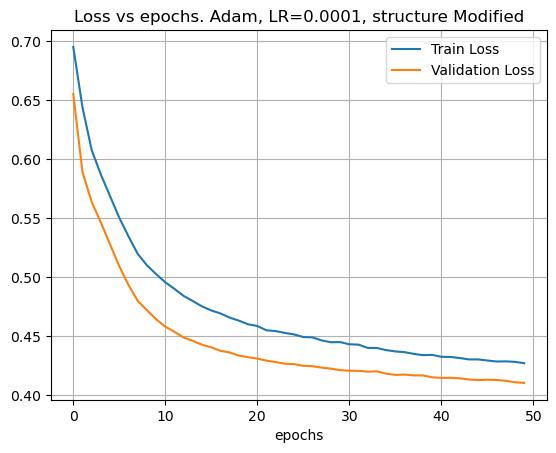

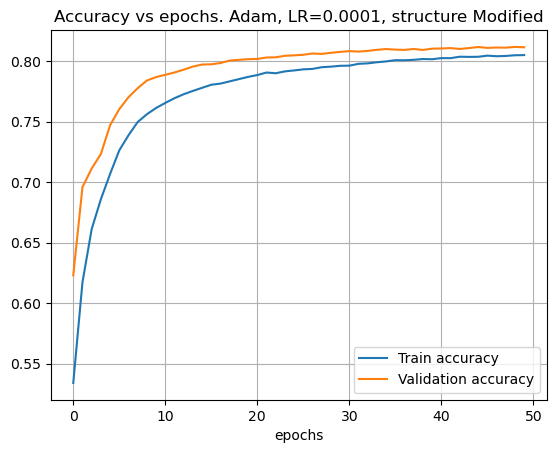

Both figures saved correctly at ./History directory


In [24]:
# a model where the network is not compressed at all, only at its end
model_NoCompress, training_NoCompress = define_mlp(optimizer = 'Adam', 
LR = 0.0001,
epochs = 50, 
Patience_Early_Stopping = 5,
batch_size = 512,
dropout_rate = 0.1,
LR_Decrease = 0,
save_plots = True,
show = True,                                           
array_neurons_hidden = [15, 15, 15, 15, 15])


Architecture defined successfully ----- [CORRECT]
Model compiled successfully ----- [CORRECT]
Callbacks defined ----- [CORRECT]
Model fully trained ----- [CORRECT]
Training duration : 149.3502218723297 secs
Best accuracy obtained (validation): 0.7440926432609558


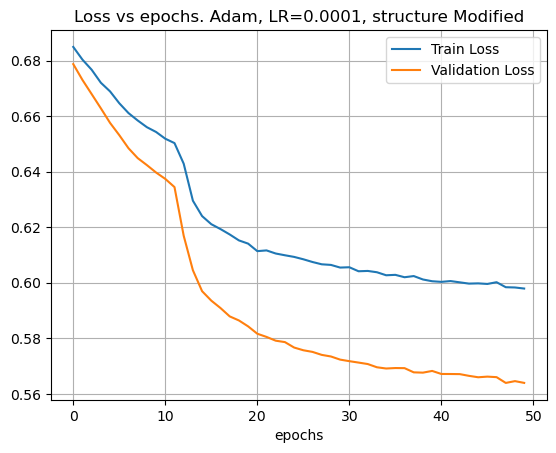

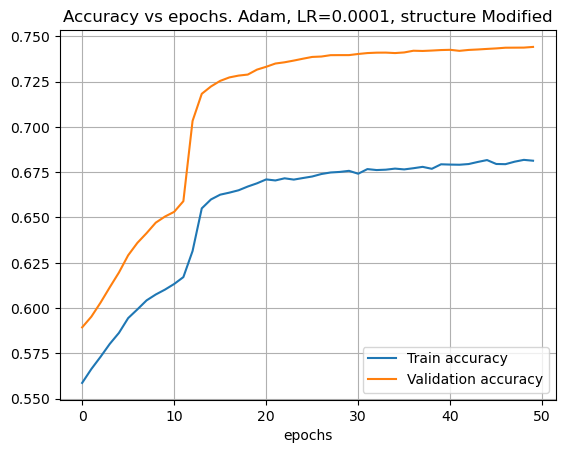

Both figures saved correctly at ./History directory


In [25]:
# diamond-shape structure. Compression-expansion-compression
# I have seen this kind of structures can reach overfitting easily, so I added a 5% extra Dropout
# https://cs.stackexchange.com/questions/88360/neural-network-shape-structure
model_dmnd, training_dmnd = define_mlp(
optimizer = 'Adam', 
LR = 0.0001,
epochs = 50, 
Patience_Early_Stopping = 5,
batch_size = 1024,
dropout_rate = 0.15,
LR_Decrease = 0,
save_plots = True,
show = True,                                           
array_neurons_hidden = [2, 5, 7, 20, 7, 5, 2])


In [26]:
# final test: trying the popular boosting algorithm XGBoost
# we will use this as a benchmark, sometimes, neural networks are too heavy to train, and 
# non-Deep Learning algorithms, like boosted-trees based, are very useful

import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

# xgboost can handle NaNs, but -999.0 will get "him" confused
x_train_nan = np.where(x_train == -999.0, np.nan, x_train)
x_val_nan = np.where(x_val == -999.0, np.nan, x_val)


model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1, 
    # tree_method='hist',
    random_state=42,
)

t0 = time.time()
print("Entrenando XGBoost...")
model.fit(x_train_nan, y_train.ravel())
print(f"Entrenamiento completado en: {time.time() - t0:.4f} secs")

probs = model.predict_proba(x_val_nan)[:, 1]

from sklearn.metrics import accuracy_score

y_pred = model.predict(x_val_nan)
y_probs = model.predict_proba(x_val_nan)[:, 1]

acc = accuracy_score(y_val, y_pred)

print("-" * 30)
print(f"ACCURACY: {acc:.4f}")
print("-" * 30)


Entrenando XGBoost...
Entrenamiento completado en: 1.6694 secs
------------------------------
ACCURACY: 0.8311
------------------------------


<strong> Copy your final (best) model whose performance will be evaluated 

In [28]:
# model_short, training_short = define_mlp(optimizer = 'Adam', 
# LR = 0.0001,
# epochs = 50, 
# Patience_Early_Stopping = 5,
# batch_size = 512,
# dropout_rate = 0.1,
# LR_Decrease = 0,
# save_plots = True,
# show = True,
# array_neurons_hidden = [40, 30, 8])

# ---------------------------------------------
# List of Layers-Neurons: [40, 30, 8]
# Time spent (training) ---> 226.47 secs
# Accuracy (validation) ---> 0.83
# ---------------------------------------------

## 9. Evaluate the DNN performance

Once you have your best model defined, it is time to evaluate its performance with the samples of the **test dataset** (be aware that this must be the **first time** over this notebook that you use your test dataset). This dataset contains samples that the DNN has not seen before, so the comparison between network predictions and ground truth gives reliable results of the network's discrimination power.

The first thing to do is to use the DNN to classify the samples contained in ```x_test``` and obtain the corresponding accuracy and loss values. To this purpose, you have to use the function ```evaluate()``` over the ```model``` object (your best model) once trained. This function takes as parameters the ```x_test``` samples, the ```y_test``` labels and the ```batch_size```.

```batch_size``` must be set to 1 in order to classify the samples one by one.

---

**TO DO: Evaluate your best model by using the test dataset. Call the results of the evaluation ```score```.**


In [38]:
evaluation = model_short.evaluate(x_test, y_test, batch_size=2048, verbose=1)
# in evaluation, batch_size does not affect to weights configuration (those are freezed once training 
# has ended), so taking bigger batch_size can enhance the performance of the evaluation process

test_loss = evaluation[0]
test_acc = evaluation[1]
print(f"Test Accuracy: {test_acc:.4f}")

probs = model_short.predict(x_test)



5/5 [==============================] - 0s 6ms/step - loss: 0.3982 - accuracy: 0.8191
Test Accuracy: 0.8191
313/313 [==============================] - 1s 3ms/step


<strong>TO DO: Save the predictions given by the network for each one of the samples of the ```x_test``` dataset in a python variable called ```y_pred```. Print this variable to understand the format in which the network predictions are given.

Note: This is the discriminant given by the network.</strong>

In [39]:
# we assume a threshold of 0.5, that might not be the most accurate, but we'll choose that one because
# our classes are balanced (in training)
y_pred = probs
print(f"Size of y_pred: {y_pred.size}")
print(f"Size of y_test: {y_test.size}")
print("----[CORRECT]----")
print("y_pred=")
print(y_pred)

Size of y_pred: 10000
Size of y_test: 10000
----[CORRECT]----
y_pred=
[[0.62276167]
 [0.39220437]
 [0.9050303 ]
 ...
 [0.55813843]
 [0.75453043]
 [0.17958042]]


### 9.1 Discriminant distribution

The discriminant distribution takes a very charactistic shape depending on how much efficient is he DNN classifying  the samples of the test dataset.

Those values are plotted for both signal and background events and in this way we can observe how the network predicts the events of each class separately (discriminant values for signal are expected to be close to 1, while background events should be close to 0).

We use ```matplotlib.pyplot``` to plot the distributions:

[0.62276167 0.39220437 0.949706   ... 0.24030142 0.55813843 0.17958042]
[0.9050303  0.46876144 0.7463046  ... 0.52300024 0.8670302  0.75453043]


<Figure size 640x480 with 0 Axes>

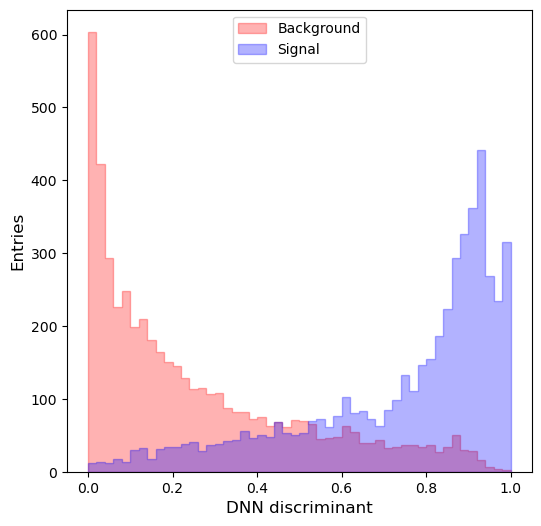

In [40]:
import os
from matplotlib import pyplot as plt

# Convert the y_pred and y_test numpy matrixes to 1-dimensional numpy arrays:
discriminant = np.squeeze(np.asarray(y_pred))
true_labels = np.squeeze(np.asarray(y_test))

# Get the discriminant values for each class (0: background, 1: signal):
discriminant0 = discriminant[list(true_labels == 0)]
print(discriminant0)
discriminant1 = discriminant[list(true_labels == 1)]
print(discriminant1)

# Define the binning:
binning = np.linspace(0, 1, 51)


# Plot the discriminant distributions:
plt.clf()
plt.figure(num=None, figsize=(6, 6))
plt.subplot(111)
pdf0, bins0, patches0 = plt.hist(discriminant0, bins = binning, color = 'r', alpha = 0.3, histtype = 'stepfilled', linewidth = 1, edgecolor='r', label = 'Background')
pdf1, bins1, patches1 = plt.hist(discriminant1, bins = binning, color = 'b', alpha = 0.3, histtype = 'stepfilled', linewidth = 1, edgecolor='b', label = 'Signal')
plt.legend(loc = 'upper center')
plt.ylabel('Entries', fontsize = 12)
plt.xlabel('DNN discriminant', fontsize = 12)
if not os.path.exists('Results/'): os.makedirs('Results/')
plt.savefig('Results/Discriminant_distribution.png', dpi = 600)

### 9.2 ROC curve

In a classification problem the main goal is to maximize the number of true classified samples but also to minimize the number of errors. That is, to obtain the higher number of true signal events classified as signal events while avoiding to classify background events as signal events.

In this context we have the following definitions:
- <font color="green"> True Positives TP: True signal events classified as signal events.</font>
- <font color="red"> Fake Positives FP: True background events classified as signal events.</font>
- <font color="red"> Fake Negatives FN: True signal events classified as background events.</font>
- <font color="green"> True Negatives TN: True background events classified as background events.</font>

>The DNN **sensitivity** is defined as the **True Positive Rate (TPR)** i.e. the ratio of True Positives obtained and the total number of true signal samples (true class == 1) in the test set:
>$$\text{TPR} = \dfrac{\text{TP}}{\text{TP} + \text{FN}}$$

> The DNN **False Positive Rate (FPR)** is defined as the ratio between the False Positives obtained and the total number of true background samples (true class == 0) in the test set:
>$$\text{FPR} = \dfrac{\text{FP}}{\text{FP} + \text{TN}}$$

Both TPR and FPR vary as we set the discriminant value over which we interpret that an event is considered as a  signal event. That is, we could say that every event with discriminant > 0.6 is classified as signal or chose another cut value (0.4, 0.5... etc). All this choices have their correspondent TPR and FPR. Our objective is to identify the discriminant cut that gives the highest TPR and lowest FPR relation.

The **ROC curve** is defined to study this choice and also evaluate the classification power of our network. It shows the TPR vs FPR relation as the cut in the discriminant varies (from 0 to 1). In Figure 9.1 we show an example of this TPR vs FPR space.

---

<img src="https://upload.wikimedia.org/wikipedia/commons/3/36/ROC_space-2.png" width="40%">

> **Figure 9.1**: ROC curve example.

---

The **Area Under the Curve (AUC)** is used to quantify the network performance. The higher it is, the more efficient the network is classifying samples. Normally we have the following criteria to evaluate the AUC value:

```.90-1 = excellent (A)```
```.80-.90 = good (B)```
```.70-.80 = fair (C)```
```.60-.70 = poor (D)```
```.50-.60 = fail (F)```

In order to implement the **ROC curve** creation in the code we use we use the python package ```sklearn``` (see [here](https://scikit-learn.org/stable/)). Inside the module ```sklearn.metrics``` there is a function ```roc_curve()``` that takes the network predictions ```y_pred``` and the ground truth ```y_test``` for the samples of the **test dataset**. The function computes the **TPR** (```tpr```) and the **FPR** (```fpr```) by scanning the possible values of the discriminant cut (```thresholds```) and returns that information contained in ```numpy.array``` objects. An example of the code implementation would be something like:

```fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)```

**AUC** can be easily computed from ```fpr``` and ```tpr``` by using another function provided by ```sklearn```:

```auc = metrics.auc(fpr, tpr)```

**TO DO: The full implementation is already done and you can check the results of your DNN by just running:** 

The optimal cut value is: 0.51567525


<Figure size 640x480 with 0 Axes>

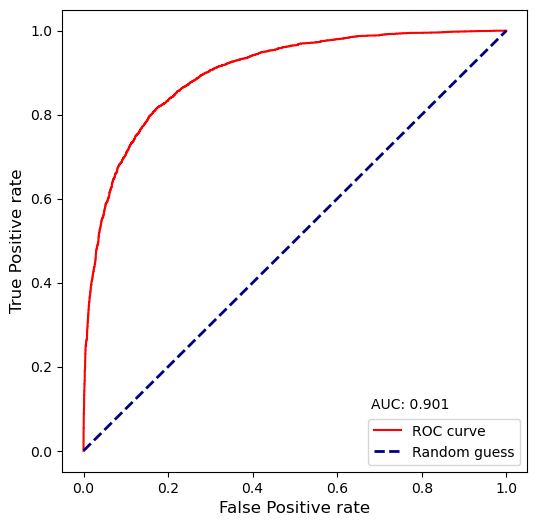

In [41]:
import os
from matplotlib import pyplot as plt
from sklearn import metrics

fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
auc = metrics.auc(fpr, tpr)

plt.clf()
plt.figure(num=None, figsize=(6, 6))
plt.subplot(111)
plt.plot(fpr, tpr, color = 'r', label = "ROC curve")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label = "Random guess")
plt.legend(loc = "lower right")
plt.xlabel('False Positive rate', fontsize = 12)
plt.ylabel('True Positive rate', fontsize = 12)
plt.text(0.68, 0.1, 'AUC: %.3f' % auc)
plt.savefig('Results/ROC.png', dpi =  600)


#### Optative and not explained (Youden index, cut value):
Youden_index = tpr - fpr
i_max = np.argmax(Youden_index)
cut_value = thresholds[i_max]

print("The optimal cut value is: " + str(cut_value))

### 9.3 Confusion matrix

Finally and with the optimal cut value in the discriminant already chosen, the results of the DNN performance can be presented in the form of a **confusion matrix**.

>Being $N$ the number of classes, the **confusion matrix** is a $N$x$N$ matrix where the rows are the true classes of the samples and the columns the class predictions given by the network. In this case the confusion matrix is a 2x2 matrix with two classes (0: background, 1: signal). The entries of the matrix are the fraction of samples of the test dataset filled in each category.

In this sense, the confusion matrix can be understood as a 2-dimensional normalized histogram.

According to this definition, the **True Positives (TP)** are stored in (1,1), **True Negatives (TN)** in (0,0), **False Positives (FP)** in (0,1) and **False Negatives (FN)** in (1,0).

**TO DO: The confusion matrix is already implemented and you can obtain the one from your model by running:** 

-> Computing confusion matrix...


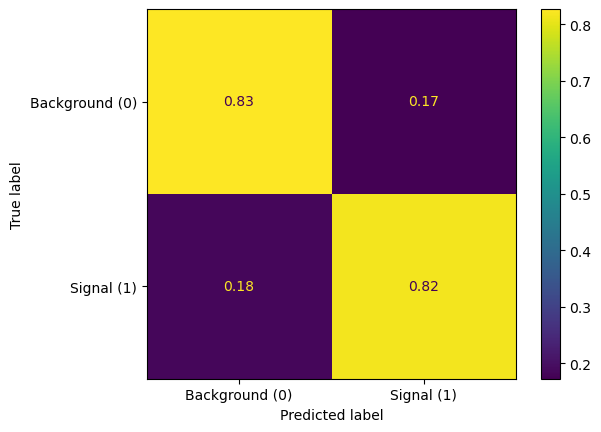

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("-> Computing confusion matrix...")

y_test_confusion = true_labels
y_pred_confusion = np.zeros(len(discriminant))

for i in range(0, len(discriminant)):
    if discriminant[i] > cut_value: # threshold
        y_pred_confusion[i] = 1
    else:
        y_pred_confusion[i] = 0
        

cnf_matrix = confusion_matrix(y_test_confusion, y_pred_confusion, normalize='true')

cmd = ConfusionMatrixDisplay(cnf_matrix, display_labels=['Background (0)', 'Signal (1)'])
cmd.plot()

if not os.path.exists('Results/'): os.makedirs('Results/')
plt.savefig("Results/ConfusionMatrix.png", dpi = 600)